# visualization.network-virus



In this notebook, we will create networks that allow us to study the interactions between virus and hosts. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import igraph  as ig
import networkx as nx
import random
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


## Virus/bacteria - host weighted matrix

In [2]:
metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")


In [3]:
virus_edges = pd.read_csv("input/network.mcleish24.links.csv", sep="\t").value_counts(['host', 'virus', 'habitat']).reset_index()
virus_nodes = pd.read_csv("input/network.mcleish24.nodes.csv", sep="\t")
virus_edges = pd.merge(virus_edges, virus_nodes[['id', 'taxon']], how='inner', left_on='host', right_on='id')
virus_edges = pd.merge(virus_edges, virus_nodes[['id', 'taxon']], how='inner', left_on='virus', right_on='id')
virus_edges = virus_edges.rename(columns={'taxon_x': 'host_taxon', 'taxon_y': 'virus_taxon'})
virus_edges['host_taxon'] = virus_edges['host_taxon'].apply(lambda x: x.replace("_", " "))
virus_host = virus_edges[['host_taxon', 'virus_taxon', 'habitat', 'count']].copy()
virus_host['type'] = 'virus'
virus_host = virus_host.rename(columns={'virus_taxon': 'scientific_name'}).copy()
virus_host

,host_taxon,scientific_name,habitat,count,type
0,Cucumis melo,CMV,Crop,21,virus
1,Convolvulus arvensis,PZSV,Edge,19,virus
2,Convolvulus arvensis,CMV,Edge,19,virus
3,Silybum marianum,CMV,Edge,17,virus
4,Silybum marianum,PZSV,Edge,16,virus
...,...,...,...,...,...
1179,Desconocida 5,RuCMV,Crop,1,virus
1180,Desconocida 5,TMGMV,Wasteland,1,virus
1181,Descurainia sophia,BMV,Wasteland,1,virus
1182,Descurainia sophia,TCV,Wasteland,1,virus


In [4]:
organism_host = pd.concat([virus_host])
organism_host

,host_taxon,scientific_name,habitat,count,type
0,Cucumis melo,CMV,Crop,21,virus
1,Convolvulus arvensis,PZSV,Edge,19,virus
2,Convolvulus arvensis,CMV,Edge,19,virus
3,Silybum marianum,CMV,Edge,17,virus
4,Silybum marianum,PZSV,Edge,16,virus
...,...,...,...,...,...
1179,Desconocida 5,RuCMV,Crop,1,virus
1180,Desconocida 5,TMGMV,Wasteland,1,virus
1181,Descurainia sophia,BMV,Wasteland,1,virus
1182,Descurainia sophia,TCV,Wasteland,1,virus


### Adjacency matrix

In [5]:
organism_host_pvt = organism_host.groupby(['host_taxon', 'scientific_name'], as_index=False)['count'].sum().pivot(index='host_taxon', columns='scientific_name', values='count').fillna(0.0)
organism_host_pvt

scientific_name,AEV1,AEYV,AGLV,ALaV,AMCV,AMMV,AMV,AMoV,AV1,AhPV1,...,WLYaV,WMV,WMoV,WSMV,WYDV,YBMV,YMV,YSV,YoMV,ZYMV
host_taxon,,,,,,,,,,,,,,,,,,,,,
Allium sativum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Amaranthus sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Anacyclus clavatus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Anchusa undulata,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andryala arenaria,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trifolium tomentosum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Verbascum sinuatum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Vicia sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
organism_host_pvt.to_csv("scratch/adjmat.virus.weighted.csv", sep=";")

### Multigraph

In [7]:
M = nx.MultiGraph()
for _, row in organism_host.drop_duplicates(subset=['scientific_name', 'type'], keep='first').iterrows():
    M.add_node(row.scientific_name, kingdom=row.type, role=row.type, scientific_name=row.scientific_name)

for _, row in organism_host.drop_duplicates(['host_taxon'], keep='first').iterrows():
    M.add_node(row.host_taxon, kingdom='host', role='host', scientific_name=row.host_taxon)

for _, row in organism_host.iterrows():
    M.add_edge(row.host_taxon, row.scientific_name, weight=row['count'], habitat=row['habitat'])

nx.write_graphml(M, "output/network.virus-host.multigraph.graphml")

### Visualization

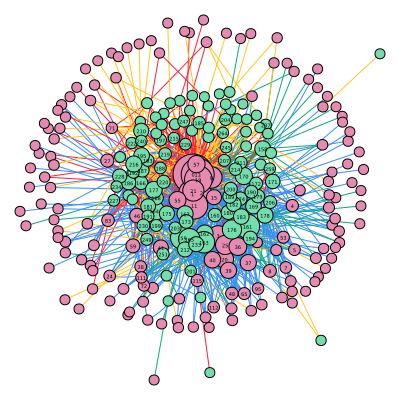

In [8]:
role_palette = {
    'host': "#73deac",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}

g = ig.read("output/network.virus-host.multigraph.graphml", format='graphml')
edge_colors = [habitat_palette[edge['habitat']] for edge in g.es]
node_colors = [role_palette[vertex['role']] for vertex in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 30 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
degree_threshold = 10

degree_threshold = 5
labels = [
    dict(num_label=str(i), label=str(v['scientific_name'])) if degree > degree_threshold else dict(num_label="", label=str("")) for i, (v, degree) in enumerate(zip(g.vs, degrees))
]
labels = pd.DataFrame.from_records(labels)

random.seed(124)
layout = g.layout("kk")
ig.plot(g, layout=layout, edge_color=edge_colors, vertex_color=node_colors, vertex_size=normalized_sizes, target="figures/virus-host.multigraph.kk-layout.svg", vertex_label=labels['num_label'], vertex_label_size=5,
    bbox=(400, 400))

## Module enrichment

In [10]:
modules = pd.read_csv("scratch/modules.virusbact.weighted.csv", sep='\t').query('type == "row"')
# modules['value'] = modules['value'].apply(lambda x: x[1:])
modules

,index,type,value
0,1,row,Klasea pinnatifida
2,2,row,Aphyllanthes monspeliensis
3,2,row,Hieracium pilosella
8,3,row,Borago officinalis
9,3,row,Lavandula latifolia
...,...,...,...
333,16,row,Jasminum fruticans
334,16,row,Rubia peregrina
357,17,row,Anacyclus clavatus
358,17,row,Convolvulus arvensis


In [11]:
modules

,index,type,value
0,1,row,Klasea pinnatifida
2,2,row,Aphyllanthes monspeliensis
3,2,row,Hieracium pilosella
8,3,row,Borago officinalis
9,3,row,Lavandula latifolia
...,...,...,...
333,16,row,Jasminum fruticans
334,16,row,Rubia peregrina
357,17,row,Anacyclus clavatus
358,17,row,Convolvulus arvensis


In [12]:
host_habitat = organism_host[['host_taxon', 'habitat']].drop_duplicates()
host_habitat

,host_taxon,habitat
0,Cucumis melo,Crop
1,Convolvulus arvensis,Edge
3,Silybum marianum,Edge
5,Diplotaxis erucoides,Edge
6,Lactuca serriola,Edge
...,...,...
1047,Hirschfeldia incana,Crop
1067,Crataegus monogyna,Oak
1079,Cyperus longus,Crop
1175,Desconocida 5,Wasteland


In [13]:
cont_table = pd.merge(
    modules, host_habitat, left_on='value', right_on='host_taxon'
).value_counts(
    ['index', 'habitat']
).reset_index().pivot(
    index='index', columns='habitat', values='count'
).fillna(0).astype(int)
cont_table

habitat,Crop,Edge,Oak,Wasteland
index,,,,
2,0,0,1,0
3,0,0,1,2
4,1,2,1,0
5,0,0,1,1
6,0,0,2,2
7,5,8,1,5
8,6,18,1,2
9,1,2,1,1
10,0,1,6,5


In [14]:
contingency_test = stats.chi2_contingency(cont_table)
print(f"p-value = {contingency_test.pvalue:8.6e}")
print(f"stat    = {contingency_test.statistic:8.6e}")
print(f"dof     = {contingency_test.dof:8d}")

p-value = 1.016437e-05
stat    = 9.731472e+01
dof     =       45


In [15]:
contingency_test.pvalue

1.0164370399918695e-05

In [16]:
modules.value_counts(['index'])

index
15       35
8        18
7        12
13        9
10        8
16        4
11        4
9         3
17        3
6         3
4         3
3         3
2         2
12        2
5         1
14        1
1         1
Name: count, dtype: int64